# Feature importance

This notebook loads the classifiers saved by notebook `01b` and computes feature importances using Gini impurity (spatially cross-validated) and permutation importance.

## Notebook setup

These cells set up the environment based on the selected config file.

### Config

In [1]:
config_file = "config/.run_config.yml"

In [2]:
from lib.paths import PathConfigManager
pcm = PathConfigManager(config_file, notebook="01")

# Base directories
output_dir = pcm.OUTPUT_DIR
points_data_dir = pcm.POINTS_DATA_DIR

pcm.create_directories()

# Input data filepaths
training_data_filepath = pcm.TRAINING_DATA_PATH

# Notebook scope
use_extracted_data = pcm.use_extracted_data
use_same_features = pcm.config["use_same_features"]
create_regional_models = pcm.config["create_regional_models"]

# Computation parameters
random_seed = pcm.config["random_seed"]
n_jobs = pcm.config["n_jobs"]
verbose = pcm.config["verbose"]
overwrite = pcm.config["overwrite_output"]

### Notebook parameters

In [3]:
# Scorer for permutation importance
# "average_precision": area under the precision-recall curve
# "recall_auc": mean predicted score for known positives
#               (equivalent to AUC of recall-vs-threshold curve)
cv_scorer = "average_precision"

### Imports

In [4]:
import warnings

import joblib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from sklearn.base import clone
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.inspection import permutation_importance
from sklearn.metrics import average_precision_score, make_scorer
from sklearn.model_selection import StratifiedGroupKFold

from lib.check_files import check_prepared_data
from lib.misc import format_feature_name

plt.style.use(pcm.CONFIG_DIR / "thesis.mplstyle")
pd.set_option('future.no_silent_downcasting', True)
%env PYTHONWARNINGS=ignore
warnings.simplefilter("ignore")

objc[92554]: Class QT_ROOT_LEVEL_POOL__THESE_OBJECTS_WILL_BE_RELEASED_WHEN_QAPP_GOES_OUT_OF_SCOPE is implemented in both /Users/glados/opt/anaconda3/envs/prospectivity/lib/libQt6Core.6.11.0.dylib (0x1aaaad738) and /Users/glados/opt/anaconda3/envs/prospectivity/lib/libQt5Core.5.15.15.dylib (0x19e62c3d0). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[92554]: Class KeyValueObserver is implemented in both /Users/glados/opt/anaconda3/envs/prospectivity/lib/libQt6Core.6.11.0.dylib (0x1aaaad760) and /Users/glados/opt/anaconda3/envs/prospectivity/lib/libQt5Core.5.15.15.dylib (0x19e62c3f8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[92554]: Class RunLoopModeTracker is implemented in both /Users/glados/opt/anaconda3/envs/prospectivity/lib/libQt6Core.6.11.0.dylib (0x1aaaad7b0) and /Users/glados/opt/anaconda3/envs/prospectivity/lib/libQt5Core.5.15.1

env: PYTHONWARNINGS=ignore


/var/folders/vn/gbv894gx5fncbnm4wbnf90080000gn/T/ipykernel_92554/4224399721.py:18: Pandas4Warning: 'future.no_silent_downcasting' is deprecated, please refrain from using it.


### Input and output files

In [ ]:
if use_extracted_data:
    print(f"Using extracted training data in {points_data_dir}")
else:
    prep_dir = check_prepared_data(pcm.PREPARED_DATA_DIR, verbose=True)
    prep_dir = Path(prep_dir)
    training_data_filepath = prep_dir / "training_data_global.csv"

pu_dir = output_dir / "PU"
pu_basename = pu_dir / "classifier"

importance_dir = pu_dir / "feature_importance"
importance_dir.mkdir(parents=True, exist_ok=True)
gini_importance_basename = importance_dir / "gini_importance"

selected_features_filepath = output_dir / "selected_features.csv"

Using extracted training data in /Users/glados/Documents/Not Useless/Documents/University/2026/Honours/Data & Code/PUB-framework-Alfonso/data_extracted/zahirovic2022/polygons_points/trenches_9.0_deg_buffer


### Plotting setup

In [7]:
FW = 150 / 25.4  # Convert 150 mm to inches for figure width

label_size = 8
tick_size = 4
title_size = 10

## Training data

Load the training dataset and reconstruct the feature matrix used to train the classifiers.

In [8]:
data = pd.read_csv(training_data_filepath)
data.columns

Index(['present_lon', 'present_lat', 'age (Ma)', 'Cu (Mt)', 'source', 'label',
       'plate_id', 'lon', 'lat', 'overriding_plate_id',
       ...
       'mantle_relative_east_velocity_lab+160km (cm/yr)',
       'mantle_relative_north_velocity_lab+160km (cm/yr)',
       'mantle_relative_speed_lab+160km (cm/yr)',
       'relative_velocity_parallel_to_plate_lab+160km (cm/yr)',
       'relative_velocity_transverse_to_plate_lab+160km (cm/yr)',
       'lab_depth_delta (km/timestep)',
       '1000k_isotherm_depth_delta (km/timestep)',
       'sublithospheric_cold_anomaly_thickness_delta (km/timestep)',
       'cold_anomaly_magnitude_delta (K/timestep)', 'region'],
      dtype='str', length=138)

### Columns to drop

In [9]:
# ---+ Coordinate columns --------------------------------------------------------

coordinate_columns = {
    "present_lon",
    "present_lat",
    "lon",
    "lat",
    "Cu (Mt)",
    "age (Ma)",
}


# ---+ Metadata columns --------------------------------------------------------

metadata_columns = {
    "region",
    "plate_id",
    "set",
    "source",
    "overriding_plate_id",
    "subducting_plate_ID",
    "trench_plate_ID",
    "arc_segment_length (degrees)",
    "trench_normal_angle (degrees)",
    "distance_from_trench_start (degrees)",
    "distance_from_trench_start (km)",
    "crustal_thickness_n",
    "bracket_infilled",
}


# ---+ Component columns --------------------------------------------------------

# Drop individual water/carbon components, only use totals
component_columns = {
    "base_lithosphere_water_thickness (m)",
    "sedimentary_bound_water_thickness (m)",
    "sedimentary_pore_water_thickness (m)",
    "mantle_lithosphere_water_thickness (m)",
    "crustal_pore_water_thickness (m)",
    "crustal_bound_water_thickness (m)",
    "subducted_carbonate_volume (m)",
    "carbonate_carbon_density (t/m^2)",
    "carbonate_thickness (m)",
    "crustal_carbon_density (t/m^2)",
}
# Use orthogonal/parallel velocity vector components
component_columns |= {
    "subducting_plate_absolute_velocity (cm/yr)",
    "convergence_rate (cm/yr)",
    "trench_velocity (cm/yr)",
}
# Drop oceanic crust thickness and convergence rate,
# only use slab flux (product of the two components)
component_columns |= {
    "convergence_rate_orthogonal (cm/yr)",
    "plate_thickness (m)",
}
# Drop orthogonal components of mantle/plate velocity to prevent spatial leakage;
# use only overall magnitude
component_columns |= {
    component for component in data.columns if "east" in component or "north" in component
}


# ---+ Preservation columns --------------------------------------------------------

preservation_columns = {
    "total_precipitation (km)",
    "total_convergence (km)",
    "erosion (m)",
}

# ---+ Final set for feature selection --------------------------------------------------------

columns_to_drop = coordinate_columns | metadata_columns | component_columns | preservation_columns

### Load training data

In [10]:
data = pd.read_csv(training_data_filepath)

data = data.drop_duplicates(subset=["lon", "lat", "age (Ma)"], keep="first")

# Skip regions with < 50 deposits
regions_to_skip = set()
for region, subset in data.groupby("region"):
    if (subset["label"] == "positive").sum() < 50:
        regions_to_skip.add(region)
data = data[~data["region"].isin(regions_to_skip)]

cleaned = data.drop(
    columns=list(columns_to_drop),
    errors="ignore",
)

print("Training data summary:")
print(data.groupby(["region", "label"]).size())

Training data summary:
region          label     
East Asia       negative         8
                positive       213
                unlabelled    6939
North America   negative        58
                positive       441
                unlabelled    7016
South America   negative       642
                positive       175
                unlabelled    7291
Southeast Asia  negative        13
                positive       143
                unlabelled    4480
Tethys          negative        12
                positive       466
                unlabelled    5199
dtype: int64


### Wrangle training data

In [11]:
data_pu = data[data["label"].isin({"positive", "unlabelled"})]

train_pu = cleaned[cleaned["label"].isin({"positive", "unlabelled"})]
features_pu = train_pu.drop(columns="label")
y_pu = train_pu["label"].replace({"positive": 1, "unlabelled": 0}).astype("int")

selected_features = pd.read_csv(selected_features_filepath)["selected_features"].tolist()
X_pu = features_pu[selected_features]

## Define spatial folds

Spatial folds divide training data into 10° × 10° × 10 Myr voxels, matching the fold design used for hyperparameter tuning in notebook `01b`.

In [12]:
lon_spacing, lat_spacing, time_spacing = 10, 10, 10

lon_grid = np.floor(data_pu["lon"] / lon_spacing) * lon_spacing
lat_grid = np.floor(data_pu["lat"] / lat_spacing) * lat_spacing
time_grid = np.floor(data_pu["age (Ma)"] / time_spacing) * time_spacing

spatial_groups, _ = pd.factorize(lon_grid + lat_grid * 100 + time_grid * 10000)

n_folds_spatial = 5
sgkf = StratifiedGroupKFold(n_splits=n_folds_spatial, shuffle=True, random_state=random_seed)

## Load classifier

Load the global PU classifier fitted in notebook `01b`.

In [15]:
pu_pipeline = joblib.load(pu_basename.with_suffix(".joblib"))
print(f"Loaded classifier from {pu_basename.with_suffix(".joblib")}")
display(pu_pipeline)

Loaded classifier from /Users/glados/Documents/Not Useless/Documents/University/2026/Honours/Data & Code/PUB-framework-Alfonso/output/all_features/PU/classifier.joblib


,steps,"[('preprocessing', ...), ('classifier', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('iterativeimputer', ...), ('robustscaler', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,estimator,None
,missing_values,nan
,sample_posterior,False


## Gini importance

Mean decrease in impurity (Gini) across spatial CV folds. Each fold refits the full pipeline on the training split and stacks importances from all inner bags, giving a distribution over spatial and bootstrap subsampling variance.

### Global model

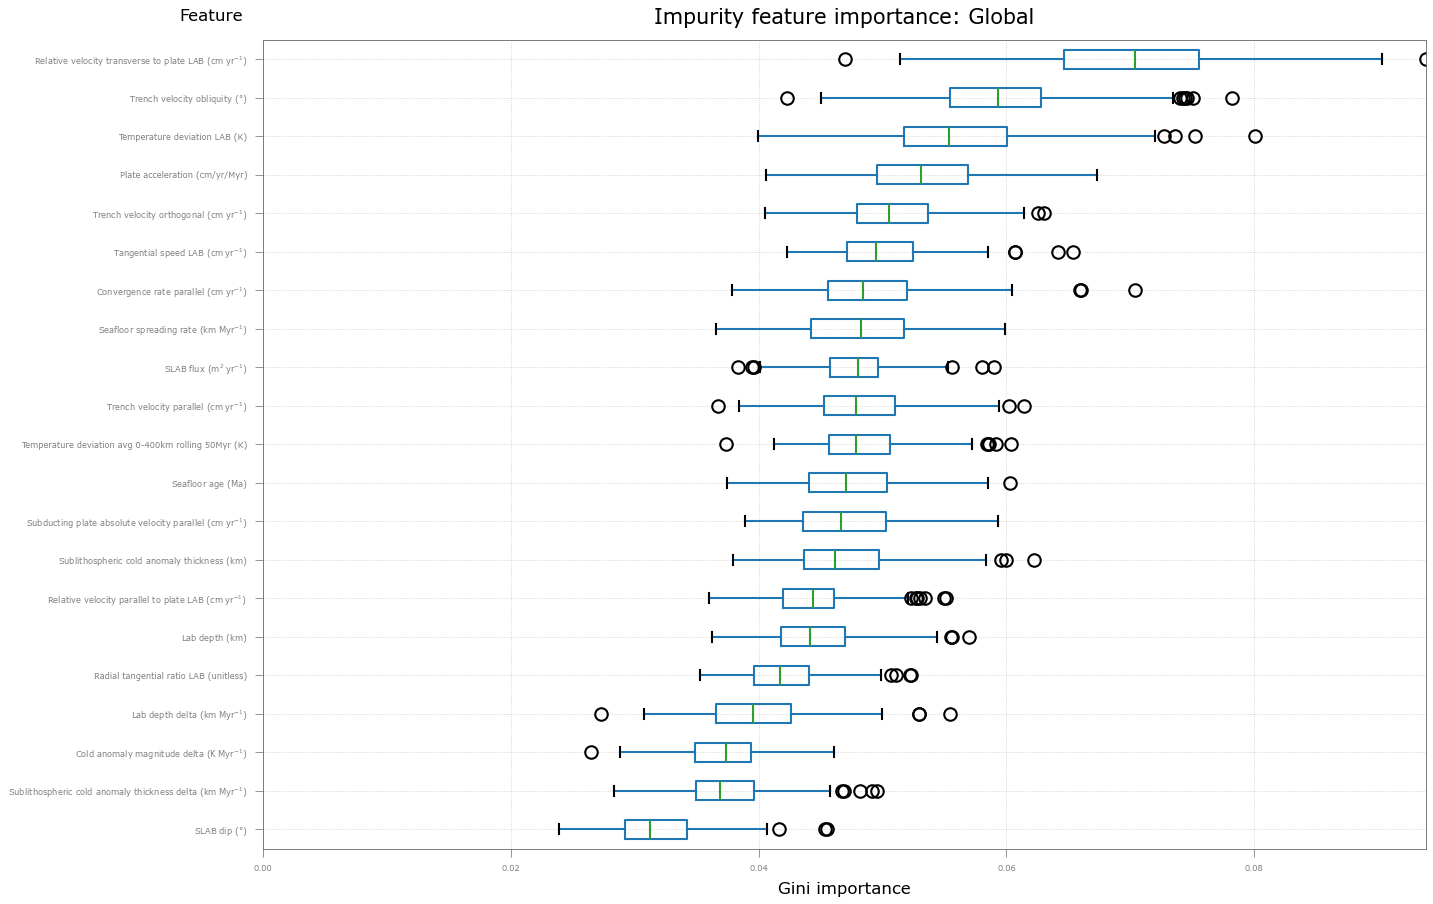

In [ ]:
feature_names = pu_pipeline.feature_names_in_

replace = {"positive": 1, "negative": 0, "unlabelled": 0}
importances = []
for train_idx, _ in sgkf.split(X_pu, y_pu, groups=spatial_groups):
    X_train = X_pu.iloc[train_idx]
    y_train = y_pu.iloc[train_idx]

    clf = clone(pu_pipeline)
    clf.fit(X_train, y_train)
    df_results = pd.DataFrame(
        np.vstack(
            [
                i.feature_importances_
                for i in clf["classifier"].estimators_
            ]
        ),
        columns=clf["preprocessing"].get_feature_names_out(),
    )
    importances.append(df_results)
importances = pd.concat(importances, ignore_index=True)
importances = importances[
    importances.median().sort_values(ascending=False).index
]
importances.to_csv(gini_importance_basename.with_suffix(".csv"), index=False)

# Plot
fig, ax = plt.subplots(figsize=(FW, max(0.2 * len(feature_names), 3)))
importances.iloc[:, ::-1].boxplot(vert=False, ax=ax)
ax.grid(linestyle="dotted")
ax.set_xlim(0)
ax.set_xlabel("Gini importance", fontsize=label_size)
ax.set_ylabel("Feature", rotation=0, ha="right", fontsize=label_size)
ax.yaxis.set_label_coords(x=-0.017, y=1.02)
ax.set_title("Impurity feature importance: Global", fontsize=title_size)
ax.set_yticks(
    ax.get_yticks(),
    [format_feature_name(i.get_text()) for i in ax.get_yticklabels()]
)
ax.tick_params(labelsize=tick_size)
for ext in (".pdf", ".png"):
    fig.savefig(gini_importance_basename.with_suffix(ext), dpi=350, bbox_inches="tight")

### Regional models

In [ ]:
for region in data["region"].unique():
    r = "_".join(region.lower().split())
    subset = data[data["region"] == region]
    subset = subset[subset["label"].isin({"positive", "unlabelled"})]

    model_path = f"{pu_basename}_{r}.joblib"
    try:
        model = joblib.load(model_path)
    except FileNotFoundError:
        raise RuntimeError(
            f"No fitted model found for {region} at {model_path}. "
            "Run the 'Train and save classifiers' section of notebook 01b first."
        )

    region_features_path = selected_features_filepath.with_name(
        f"{selected_features_filepath.stem}_{region.lower().replace(' ', '_')}.csv"
    )
    region_features = pd.read_csv(region_features_path)["selected_features"].tolist()

    train_pu_region = cleaned[
        (cleaned.index.isin(subset.index)) & (cleaned["label"] != "negative")
    ]
    X_pu_region = train_pu_region[region_features]
    y_pu_region = train_pu_region["label"].replace(replace).infer_objects()

    spatial_groups_region, _ = pd.factorize(
        np.floor(subset["lon"] / 10) * 10
        + np.floor(subset["lat"] / 10) * 100
        + np.floor(subset["age (Ma)"] / 10) * 10000
    )
    sgkf_region = StratifiedGroupKFold(n_splits=n_folds_spatial, shuffle=True, random_state=random_seed)

    importances = []
    for train_idx, _ in sgkf_region.split(X_pu_region, y_pu_region, groups=spatial_groups_region):
        X_train = X_pu_region.iloc[train_idx]
        y_train = y_pu_region.iloc[train_idx]
        clf = clone(model)
        clf.fit(X_train, y_train)
        df_results = pd.DataFrame(
            np.vstack([i.feature_importances_ for i in clf["classifier"].estimators_]),
            columns=clf["preprocessing"].get_feature_names_out(),
        )
        importances.append(df_results)
    importances = pd.concat(importances, ignore_index=True)
    importances = importances[
        importances.median().sort_values(ascending=False).index
    ]
    importances.to_csv(f"{gini_importance_basename}_{r}.csv", index=False)

    fig, ax = plt.subplots(figsize=(10, 7))
    importances.iloc[:, ::-1].boxplot(vert=False, ax=ax)
    ax.grid(linestyle="dotted")
    ax.set_xlim(0)
    ax.set_xlabel("Gini importance", fontsize=label_size)
    ax.set_ylabel("Feature", rotation=0, ha="right", fontsize=label_size)
    ax.yaxis.set_label_coords(x=-0.017, y=1.02)
    ax.set_title(f"Impurity feature importance: {region}", fontsize=title_size)
    ax.set_yticks(
        ax.get_yticks(),
        [format_feature_name(i.get_text()) for i in ax.get_yticklabels()]
    )
    ax.tick_params(labelsize=tick_size)
    for ext in (".pdf", ".png"):
        fig.savefig(f"{gini_importance_basename}_{r}{ext}", dpi=350, bbox_inches="tight")

## Permutation importance

Permutation importance is computed by measuring how much the model score drops when a feature is randomly shuffled. Unlike Gini impurity, it is evaluated on held-out data and reflects generalisation. Spatial folds are used to reduce optimistic bias from spatially autocorrelated features.

The scorer is controlled by the `cv_scorer` parameter set above.

### Global model

In [ ]:
def _recall_auc(y_true, y_score):
    """Mean predicted score for positives — equivalent to AUC of recall-vs-threshold curve."""
    return float(np.mean(y_score[y_true == 1]))

if cv_scorer == "average_precision":
    perm_scorer = make_scorer(average_precision_score, needs_proba=True)
elif cv_scorer == "recall_auc":
    perm_scorer = make_scorer(_recall_auc, needs_proba=True)
else:
    raise ValueError(f"Unknown cv_scorer: {cv_scorer!r}. Use 'average_precision' or 'recall_auc'.")

perm_importances_list = []
for fold, (train_idx, test_idx) in enumerate(sgkf.split(X_pu, y_pu, groups=spatial_groups)):
    X_train, y_train = X_pu.iloc[train_idx], y_pu.iloc[train_idx]
    X_test, y_test = X_pu.iloc[test_idx], y_pu.iloc[test_idx]
    print(f"Fold {fold + 1}/{n_folds_spatial}")
    clf = clone(pu_pipeline)
    clf.fit(X_train, y_train)
    result = permutation_importance(
        clf, X_test, y_test,
        scoring=perm_scorer,
        n_repeats=10,
        random_state=random_seed,
        n_jobs=n_jobs,
    )
    # result.importances shape: (n_features, n_repeats)
    perm_importances_list.append(
        pd.DataFrame(result.importances.T, columns=X_pu.columns)
    )

perm_importances = pd.concat(perm_importances_list, ignore_index=True)
perm_importances = perm_importances[
    perm_importances.median().sort_values(ascending=False).index
]
perm_importances.to_csv(
    importance_dir / f"permutation_importance_{cv_scorer}.csv", index=False
)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))
perm_importances.iloc[:, ::-1].boxplot(vert=False, ax=ax)
ax.grid(linestyle="dotted")
ax.axvline(0, color="0.4", linestyle="--", linewidth=0.8)
ax.set_xlabel(f"Permutation importance ({cv_scorer})", fontsize=label_size)
ax.set_ylabel("Feature", rotation=0, ha="right", fontsize=label_size)
ax.yaxis.set_label_coords(x=-0.017, y=1.02)
ax.set_title("Permutation feature importance: Global", fontsize=title_size)
ax.set_yticks(
    ax.get_yticks(),
    [format_feature_name(i.get_text()) for i in ax.get_yticklabels()]
)
ax.tick_params(labelsize=tick_size)
for ext in (".pdf", ".png"):
    fig.savefig(
        importance_dir / f"permutation_importance_{cv_scorer}{ext}",
        dpi=350,
        bbox_inches="tight",
    )